In [ ]:
# 查看当前目录下文件列表
list.files('./test_data/pbmc3k')

[1] "barcodes.tsv" "genes.tsv"    "matrix.mtx"

In [ ]:
library(Seurat)
# 读取单细胞数据
sc_obj <- Read10X(data.dir = './test_data/pbmc3k')
# 创建 Seurat 对象
sc_obj <- CreateSeuratObject(sc_obj, project = 'pbmc3k', min.cells = 3, min.features = 200)
# 查看对象基本信息
print(sc_obj)

载入需要的程序包：SeuratObject



载入需要的程序包：sp




载入程序包：'SeuratObject'




The following objects are masked from 'package:base':

    intersect, t




Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"


An object of class Seurat 
13714 features across 2700 samples within 1 assay 
Active assay: RNA (13714 features, 0 variable features)
 1 layer present: counts


In [ ]:
# 查看细胞和基因的数量
ncol(sc_obj)
nrow(sc_obj)

[1] 2700

[1] 13714

In [ ]:
# 查看前几行的基因名
head(rownames(sc_obj))

[1] "AL627309.1"    "AP006222.2"    "RP11-206L10.2" "RP11-206L10.9"
[5] "LINC00115"     "NOC2L"

In [ ]:
# 查看前几行的细胞名
head(colnames(sc_obj))

[1] "AAACATACAACCAC-1" "AAACATTGAGCTAC-1" "AAACATTGATCAGC-1" "AAACCGTGCTTCCG-1"
[5] "AAACCGTGTATGCG-1" "AAACGCACTGGTAC-1"

In [ ]:
head(sc_obj@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA
,<fct>,<dbl>,<int>
AAACATACAACCAC-1,pbmc3k,2419,779
AAACATTGAGCTAC-1,pbmc3k,4903,1352
AAACATTGATCAGC-1,pbmc3k,3147,1129
AAACCGTGCTTCCG-1,pbmc3k,2639,960
AAACCGTGTATGCG-1,pbmc3k,980,521
AAACGCACTGGTAC-1,pbmc3k,2163,781


In [ ]:
# 计算线粒体基因占比
sc_obj[['percent.mt']] <- PercentageFeatureSet(object = sc_obj, pattern = '^MT-', assay = 'RNA')

Warning message:
"The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>."


Warning message:
"`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>."


Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>."


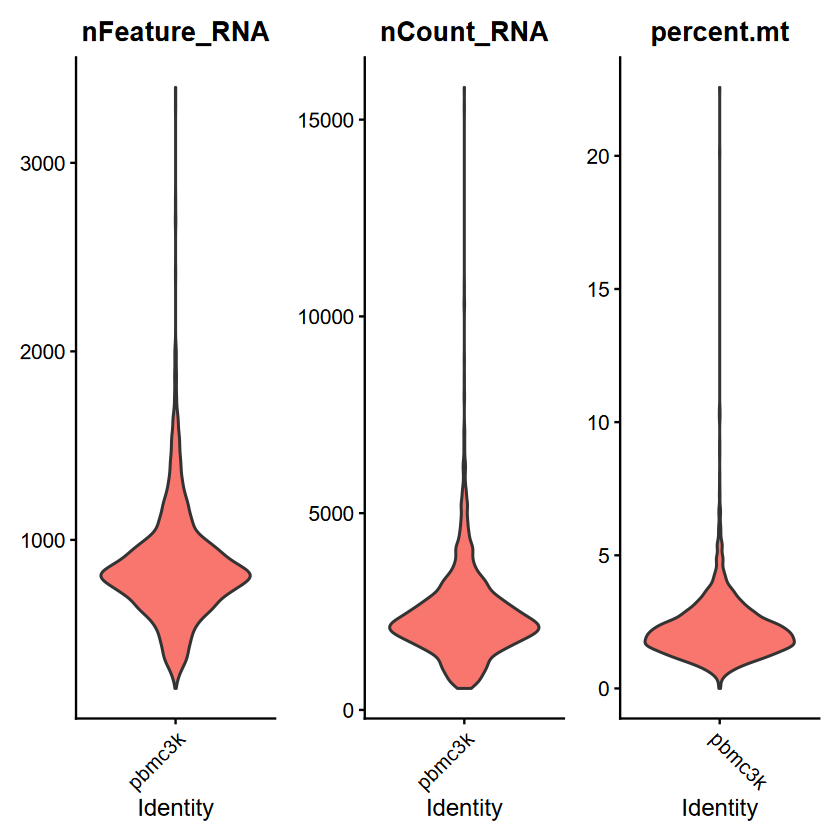

In [ ]:
library(ggplot2)
# 绘制质量控制相关分布图
VlnPlot(object = sc_obj, features = c('nFeature_RNA', 'nCount_RNA', 'percent.mt'), group.by = 'orig.ident', layer = 'counts', pt.size = 0) + theme(axis.text.x = element_text(angle = -45, hjust = 0, vjust = 1))

In [ ]:
# 根据质量控制阈值过滤细胞
sc_obj <- subset(x = sc_obj, subset = nFeature_RNA > 200 & nFeature_RNA < 2500 & percent.mt < 5)

In [ ]:
# 加载必需的 R 包
library(Seurat)
library(ggplot2)

In [ ]:
# 定义细胞周期基因列表
s.genes <- cc.genes$s.genes
g2m.genes <- cc.genes$g2m.genes

In [ ]:
# 计算细胞周期得分
sc_obj <- NormalizeData(sc_obj)
sc_obj <- CellCycleScoring(sc_obj, s.features = s.genes, g2m.features = g2m.genes, set.ident = TRUE)
# 查看细胞周期得分结果
head(sc_obj@meta.data)

Normalizing layer: counts



Warning message:
"The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>."


Warning message:
"The following features are not present in the object: DTL, UHRF1, MLF1IP, EXO1, CASP8AP2, BRIP1, E2F8, not searching for symbol synonyms"


Warning message:
"The following features are not present in the object: FAM64A, BUB1, HJURP, CDCA3, TTK, CDC25C, DLGAP5, CDCA2, ANLN, GAS2L3, not searching for symbol synonyms"


,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,S.Score,G2M.Score,Phase,old.ident
,<fct>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<fct>
AAACATACAACCAC-1,pbmc3k,2419,779,3.0177759,0.09853841,-0.044716507,S,pbmc3k
AAACATTGAGCTAC-1,pbmc3k,4903,1352,3.7935958,-0.02364305,-0.046889929,G1,pbmc3k
AAACATTGATCAGC-1,pbmc3k,3147,1129,0.8897363,-0.02177266,0.074841537,G2M,pbmc3k
AAACCGTGCTTCCG-1,pbmc3k,2639,960,1.7430845,0.03794398,0.006575446,S,pbmc3k
AAACCGTGTATGCG-1,pbmc3k,980,521,1.2244898,-0.03309970,0.027910063,G2M,pbmc3k
AAACGCACTGGTAC-1,pbmc3k,2163,781,1.6643551,-0.04814181,-0.078164839,G1,pbmc3k


In [ ]:
# 识别高变基因（默认2000个）
sc_obj <- FindVariableFeatures(sc_obj, selection.method = 'vst', nfeatures = 2000)
# 缩放数据
sc_obj <- ScaleData(sc_obj)

Finding variable features for layer counts



Centering and scaling data matrix



PC_ 1 
Positive:  CST3, TYROBP, LST1, AIF1, FTL, FTH1, LYZ, FCN1, S100A9, TYMP 
	   FCER1G, CFD, LGALS1, S100A8, CTSS, LGALS2, SERPINA1, IFITM3, SPI1, CFP 
	   PSAP, IFI30, SAT1, COTL1, S100A11, NPC2, GRN, LGALS3, GSTP1, PYCARD 
Negative:  MALAT1, LTB, IL32, IL7R, CD2, B2M, ACAP1, CD27, STK17A, CTSW 
	   CD247, GIMAP5, AQP3, CCL5, SELL, TRAF3IP3, GZMA, MAL, CST7, ITM2A 
	   MYC, GIMAP7, HOPX, BEX2, LDLRAP1, GZMK, ETS1, ZAP70, TNFAIP8, RIC3 
PC_ 2 
Positive:  CD79A, MS4A1, TCL1A, HLA-DQA1, HLA-DQB1, HLA-DRA, LINC00926, CD79B, HLA-DRB1, CD74 
	   HLA-DMA, HLA-DPB1, HLA-DQA2, CD37, HLA-DRB5, HLA-DMB, HLA-DPA1, FCRLA, HVCN1, LTB 
	   BLNK, P2RX5, IGLL5, IRF8, SWAP70, ARHGAP24, FCGR2B, SMIM14, PPP1R14A, C16orf74 
Negative:  NKG7, PRF1, CST7, GZMB, GZMA, FGFBP2, CTSW, GNLY, B2M, SPON2 
	   CCL4, GZMH, FCGR3A, CCL5, CD247, XCL2, CLIC3, AKR1C3, SRGN, HOPX 
	   TTC38, APMAP, CTSC, S100A4, IGFBP7, ANXA1, ID2, IL32, XCL1, RHOC 
PC_ 3 
Positive:  HLA-DQA1, CD79A, CD79B, HLA-DQB1, HLA-DPB1, HLA-DPA

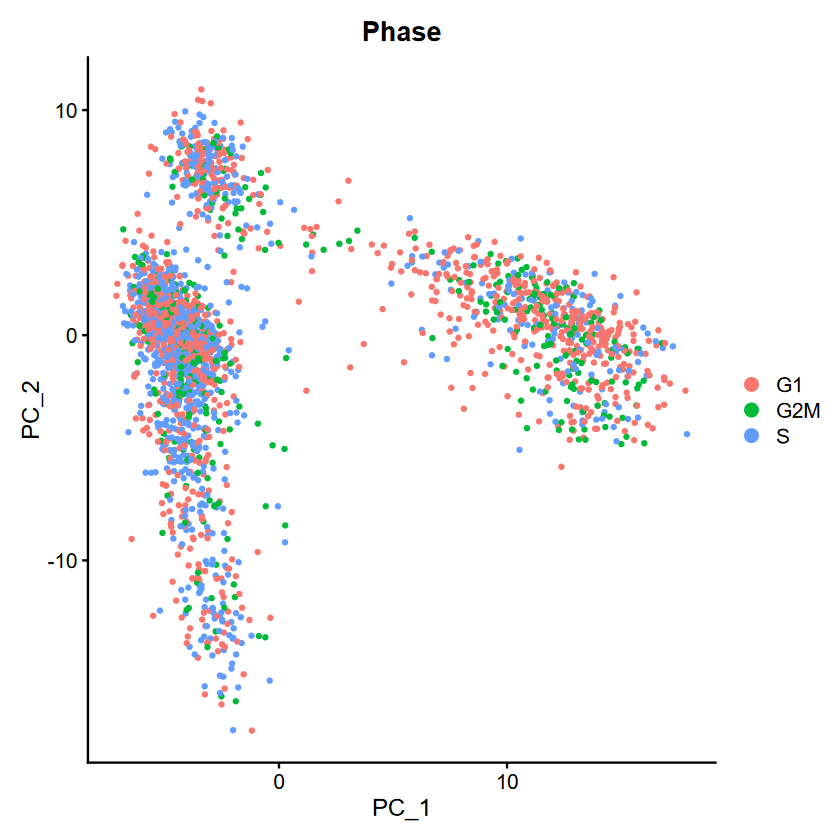

In [ ]:
# 运行 PCA 降维
sc_obj <- RunPCA(sc_obj)
# 可视化细胞周期在 PCA 上的分布
DimPlot(sc_obj, reduction = 'pca', group.by = 'Phase')

In [ ]:
# LogNormalize 标准化
sc_obj <- NormalizeData(sc_obj, normalization.method = 'LogNormalize', scale.factor = 10000)
# 识别高变基因（用于后续分析）
sc_obj <- FindVariableFeatures(sc_obj, selection.method = 'vst', nfeatures = 2000)
# 缩放数据
sc_obj <- ScaleData(sc_obj)

Normalizing layer: counts



Finding variable features for layer counts



Centering and scaling data matrix



In [ ]:
# SCTransform 标准化（务必先完成细胞周期得分计算）
sc_obj <- SCTransform(sc_obj, vars.to.regress = c('percent.mt', 'S.Score', 'G2M.Score'), return.only.var.genes = FALSE)
# 准备差异分析所需数据
sc_obj <- PrepSCTFindMarkers(object = sc_obj)

Running SCTransform on assay: RNA



vst.flavor='v2' set. Using model with fixed slope and excluding poisson genes.



Calculating cell attributes from input UMI matrix: log_umi



Variance stabilizing transformation of count matrix of size 12519 by 2638



Model formula is y ~ log_umi



...

Regressing out percent.mt, S.Score, G2M.Score



Centering data matrix



Place corrected count matrix in counts slot



Set default assay to SCT



Only one SCT model is stored - skipping recalculating corrected counts



In [ ]:
# 加载所需 R 包
library(Seurat)
library(SeuratWrappers)
library(reticulate)

In [ ]:
# 使用 scVI 方法进行集成分析
# 注意：确保已设置好 conda 环境路径
seurat_use <- IntegrateLayers(
  object = sc_obj,
  method = scVIIntegration,
  orig.reduction = NULL,
  assay = 'RNA',
  new.reduction = 'integrated.scvi',
  conda_env = 'C:/ProgramData/miniconda3/envs/scvi-env',
  verbose = TRUE
)

In [ ]:
# 加载所需 R 包
library(Seurat)
library(clustree)
library(patchwork)

载入需要的程序包：ggraph




载入程序包：'ggraph'




The following object is masked from 'package:sp':

    geometry




In [ ]:
seurat_use = sc_obj
# 在 integrated.scvi 降维空间中进行细胞聚类分析
reduction_use <- 'pca'
number_reduction <- 30
seurat_use <- FindNeighbors(object = seurat_use, reduction = reduction_use, dims = 1:number_reduction, k.param = 20)
# 尝试多个分辨率参数进行聚类
seq <- seq(0.1, 1.0, by = 0.1)
for(res in seq){
    seurat_use <- FindClusters(seurat_use, resolution = res, n.start = 10, n.iter = 10, algorithm = 4, graph.name = 'RNA_snn')
}

Computing nearest neighbor graph



Computing SNN



Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."


Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."


Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."


...

Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."


Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."


Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."


Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."


Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."


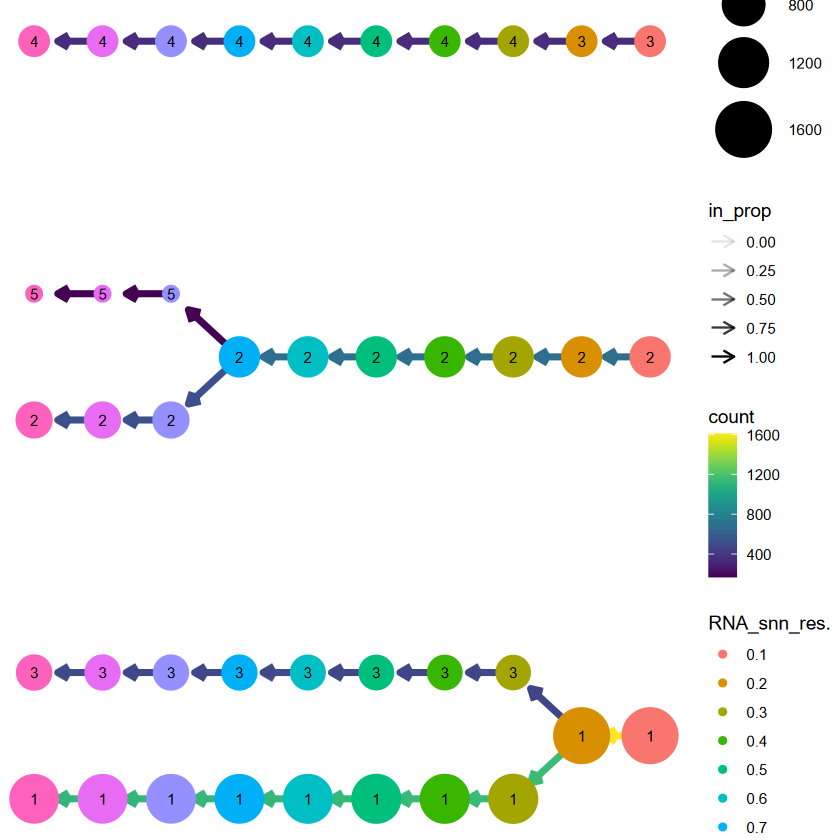

In [ ]:
# 使用 clustree 可视化不同分辨率下的聚类结果，辅助选择最优分辨率
p1 <- clustree(seurat_use, node_label_size = 5, prefix = 'RNA_snn_res.') + coord_flip()
print(p1)

In [ ]:
# 根据 clustree 结果选择最优分辨率（例如 0.4）进行最终聚类
seurat_use <- FindClusters(object = seurat_use, resolution = 0.1, n.start = 10, n.iter = 20, algorithm = 4, graph.name = 'RNA_snn')
# 查看最终聚类结果
head(seurat_use@meta.data)

Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."


,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,S.Score,G2M.Score,Phase,old.ident,RNA_snn_res.0.1,seurat_clusters,RNA_snn_res.0.2,RNA_snn_res.0.3,RNA_snn_res.0.4,RNA_snn_res.0.5,RNA_snn_res.0.6,RNA_snn_res.0.7,RNA_snn_res.0.8,RNA_snn_res.0.9,RNA_snn_res.1
,<fct>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
AAACATACAACCAC-1,pbmc3k,2419,779,3.0177759,0.09853841,-0.044716507,S,pbmc3k,1,1,1,1,1,1,1,3,3,3,3
AAACATTGAGCTAC-1,pbmc3k,4903,1352,3.7935958,-0.02364305,-0.046889929,G1,pbmc3k,3,3,3,4,4,4,4,4,4,4,4
AAACATTGATCAGC-1,pbmc3k,3147,1129,0.8897363,-0.02177266,0.074841537,G2M,pbmc3k,1,1,1,1,1,1,1,1,1,1,1
AAACCGTGCTTCCG-1,pbmc3k,2639,960,1.7430845,0.03794398,0.006575446,S,pbmc3k,2,2,2,2,2,2,2,2,2,2,2
AAACCGTGTATGCG-1,pbmc3k,980,521,1.2244898,-0.03309970,0.027910063,G2M,pbmc3k,1,1,1,3,3,3,3,3,3,3,3
AAACGCACTGGTAC-1,pbmc3k,2163,781,1.6643551,-0.04814181,-0.078164839,G1,pbmc3k,1,1,1,1,1,1,1,1,1,1,1


In [ ]:
# 加载所需 R 包
library(Seurat)
library(ggplot2)
library(scatterpie)
library(ggrepel)
library(dplyr)
library(tidyr)
library(ggrastr)
library(legendry)

scatterpie v0.2.5 Learn more at https://yulab-smu.top/






载入程序包：'scatterpie'




The following object is masked from 'package:sp':

    recenter





载入程序包：'dplyr'




The following objects are masked from 'package:stats':

    filter, lag




The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




In [ ]:
# 使用 integrated.scvi 坐标进行 tSNE 降维
seurat_use <- RunTSNE(seurat_use, reduction = 'integrated.scvi', dims = 1:30, perplexity = 30, n_iter = 1000)
# 查看 tSNE 结果
print(seurat_use[['tsne']])

In [ ]:
# 使用 integrated.scvi 坐标进行 UMAP 降维
seurat_use <- RunUMAP(seurat_use, reduction = "pca", dims = 1:30, n.neighbors = 30, min.dist = 0.5, spread = 1)
# 查看 UMAP 结果
print(seurat_use[['umap']])

Warning message:
"The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session"


16:43:34 UMAP embedding parameters a = 0.583 b = 1.334



16:43:34 Read 2638 rows and found 30 numeric columns



16:43:34 Using Annoy for neighbor search, n_neighbors = 30



16:43:34 Building Annoy index with metric = cosine, n_trees = 50



...

 with target n_neighbors = 30



16:43:35 Initializing from normalized Laplacian + noise (using RSpectra)



16:43:35 Commencing optimization for 500 epochs, with 109772 positive edges



16:43:35 Using rng type: pcg



16:43:41 Optimization finished



In [ ]:
# 加载所需 R 包
library(Seurat)
library(SeuratWrappers)
library(reticulate)
library(scatterpie)
library(ggrepel)
library(dplyr)
library(tidyr)
library(ggrastr)
library(legendry)

In [ ]:
# 运行 UMAP 降维
reduction_use = 'integrated.scvi'
scviSelect = 30
seurat_use <- RunUMAP(object = seurat_use, dims = 1:scviSelect, n.neighbors = 30, reduction = reduction_use)

14:11:42 UMAP embedding parameters a = 0.9922 b = 1.112



14:11:42 Read 2638 rows and found 30 numeric columns



14:11:42 Using Annoy for neighbor search, n_neighbors = 30



14:11:42 Building Annoy index with metric = cosine, n_trees = 50



0%   10   20   30   40   50   60   70   80   90   100%



...

 with target n_neighbors = 30



14:11:44 Initializing from normalized Laplacian + noise (using RSpectra)



14:11:44 Commencing optimization for 500 epochs, with 95684 positive edges



14:11:44 Using rng type: pcg



14:11:50 Optimization finished




TRUE 
2638 

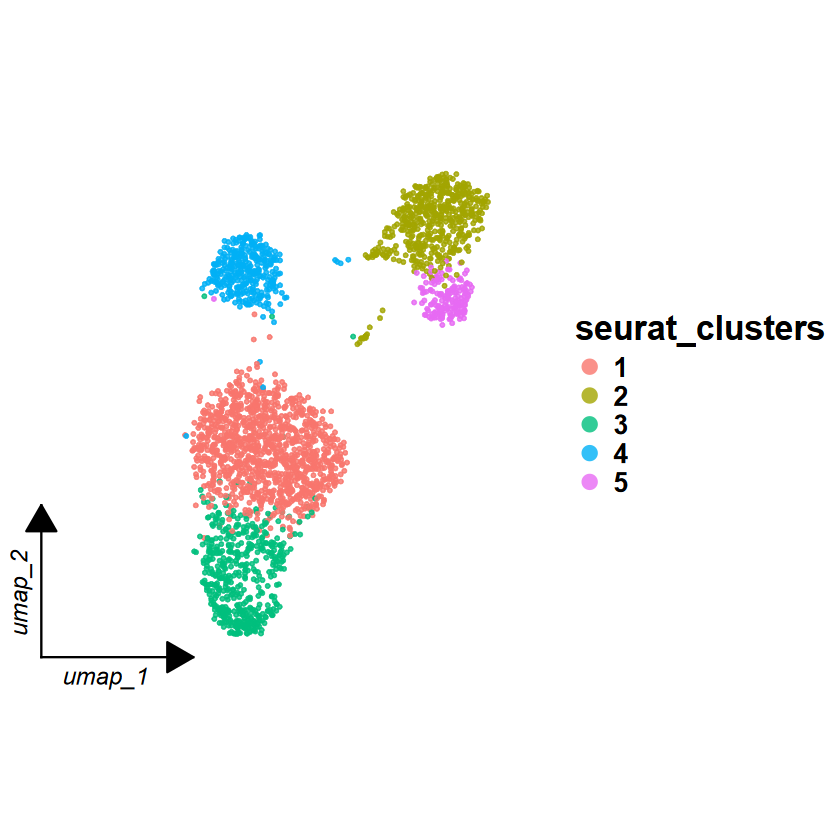

In [ ]:
# 提取 UMAP 坐标并绘制可视化图
position_umap = seurat_use@reductions$umap@cell.embeddings
table(rownames(seurat_use@meta.data)==rownames(position_umap))
frame = cbind(seurat_use@meta.data, position_umap)
axis = legendry::guide_axis_base(cap = I(c(-Inf, 0.3)))
# 计算 umap_1 和 umap_2 的范围
umap_1_range <- range(frame$umap_1)
umap_2_range <- range(frame$umap_2)
common_range <- range(c(umap_1_range, umap_2_range))
# 绘制 UMAP 图
p <- ggplot(frame, aes(x = umap_1, y = umap_2, color = seurat_clusters)) +
  geom_point_rast(size = 0.8, alpha = 0.8) +
  theme_classic() +
  theme(
    text = element_text(size = 20, color = 'black', face = 'bold', family = 'sans'),
    aspect.ratio = 1,
    panel.background = element_blank(),
    panel.grid = element_blank(),
    axis.line = element_line(arrow = arrow(type = 'closed')),
    axis.title = element_text(hjust = 0.05, face = 'italic', size = 14)
  ) +
  scale_x_continuous(breaks = NULL, limits = common_range) +
  scale_y_continuous(breaks = NULL, limits = common_range) +
  guides(x = axis, y = axis) +
  guides(color = guide_legend(override.aes = list(shape = 16, size = 4))) +
  coord_fixed()
print(p)

In [ ]:
table(seurat_use@meta.data$seurat_clusters)


   1    2    3    4    5 
1117  516  489  349  167 

In [ ]:
# 加载 Seurat 包
library(Seurat)
# 如果已有 seurat_use 对象，则直接使用；否则需先加载数据并创建对象
# 假设 seurat_use 已在之前步骤中定义

In [ ]:
# 使用 JoinLayers 函数整合多层数据（如 SCT 和 RNA）
seurat_use <- JoinLayers(seurat_use)
# 查看对象基本信息
print(seurat_use)

An object of class Seurat 
13714 features across 2638 samples within 1 assay 
Active assay: RNA (13714 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: pca, integrated.scvi, tsne, umap


In [ ]:
# 计算每个 cluster 的正向 marker 基因（仅保留高表达基因）
markers_positive <- FindAllMarkers(seurat_use, only.pos = TRUE, assay = 'RNA')
# 按 avg_log2FC 排序
markers_positive <- markers_positive[order(markers_positive$avg_log2FC, decreasing = TRUE), ]
# 计算表达比例差异
markers_positive$diff.pct <- markers_positive$`pct.1` - markers_positive$`pct.2`
# 再按 diff.pct 排序
markers_positive <- markers_positive[order(markers_positive$diff.pct, decreasing = TRUE), ]

Calculating cluster 1



Calculating cluster 2



Calculating cluster 3



Calculating cluster 4



Calculating cluster 5



In [ ]:
head(markers_positive)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene,diff.pct
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>,<dbl>
CD79A,0.000000e+00,6.733428,0.917,0.042,0.000000e+00,4,CD79A,0.875
LGALS2,0.000000e+00,6.045751,0.888,0.050,0.000000e+00,2,LGALS2,0.838
FCGR3A1,4.839141e-180,4.039724,0.952,0.134,6.636398e-176,5,FCGR3A,0.818
S100A8,0.000000e+00,6.611278,0.926,0.119,0.000000e+00,2,S100A8,0.807
IFITM31,9.901971e-149,3.317584,0.976,0.175,1.357956e-144,5,IFITM3,0.801
MS4A1,0.000000e+00,5.688294,0.837,0.054,0.000000e+00,4,MS4A1,0.783


In [ ]:
# 输出每个 cluster 的前 20 个 marker 基因
for(cluster in unique(seurat_use@meta.data$seurat_clusters)) {
  markers_positive_tmp <- markers_positive[markers_positive$cluster == cluster, ]
  print(paste('cluster', cluster, '的前20个marker基因是:'))
  print(rownames(markers_positive_tmp)[1:20])
}

[1] "cluster 3 的前20个marker基因是:"
 [1] "NKG7"     "GZMA"     "CST7"     "CCL5"     "CTSW"     "PRF1"    
 [7] "GZMM"     "GZMB"     "FGFBP2"   "GZMH"     "HOPX"     "CCL4"    
[13] "GNLY"     "LYAR"     "GZMK"     "CD247"    "KLRG1"    "IL321"   
[19] "PTPRCAP"  "APOBEC3G"
[1] "cluster 4 的前20个marker基因是:"
 [1] "CD79A"     "MS4A1"     "CD79B"     "HLA-DQA1"  "HLA-DQB1"  "TCL1A"    
 [7] "HLA-DRB11" "HLA-DRB51" "HLA-DPA11" "LINC00926" "HLA-DPB11" "HLA-DRA1" 
[13] "HLA-DMA1"  "VPREB3"    "BANK1"     "HLA-DQA21" "HVCN1"     "HLA-DMB1" 
[19] "FCER2"     "TSPAN13"  
[1] "cluster 1 的前20个marker基因是:"
 [1] "CD3D"    "CD3E"    "IL32"    "IL7R"    "LDHB"    "LTB"     "NOSIP"  
 [8] "CD2"     "CD7"     "AES"     "LCK"     "CD27"    "CCR7"    "PIK3IP1"
[15] "EVL"     "LEF1"    "AQP3"    "TRAT1"   "RGCC"    "GIMAP7" 
[1] "cluster 2 的前20个marker基因是:"
 [1] "LGALS2" "S100A8" "FCN1"   "S100A9" "CST3"   "LST1"   "TYROBP" "FCER1G"
 [9] "AIF1"   "TYMP"   "MS4A6A" "GRN"    "GPX1"   "CFD"    "CD14"   "LGALS1"
[17

In [ ]:
# 定义每个 cluster 对应的细胞类型及 marker 基因
cell_type_markers <- list(
  'Tcell' = c('CD3D', 'CD3E', 'IL7R', 'CD2', 'CD7'),
  'Bcell' = c('CD79A', 'MS4A1', 'CD79B', 'HLA-DQA1', 'HLA-DQB1'),
  'Mono_Macro' = c('S100A8', 'S100A9', 'CD14', 'TYROBP', 'FCER1G'),
  'NK' = c('NKG7', 'GZMA', 'CST7', 'CCL5', 'PRF1'),
  'Neu' = c('FCGR3A', 'IFITM3', 'SERPINA1', 'CD68', 'SPI1')
)

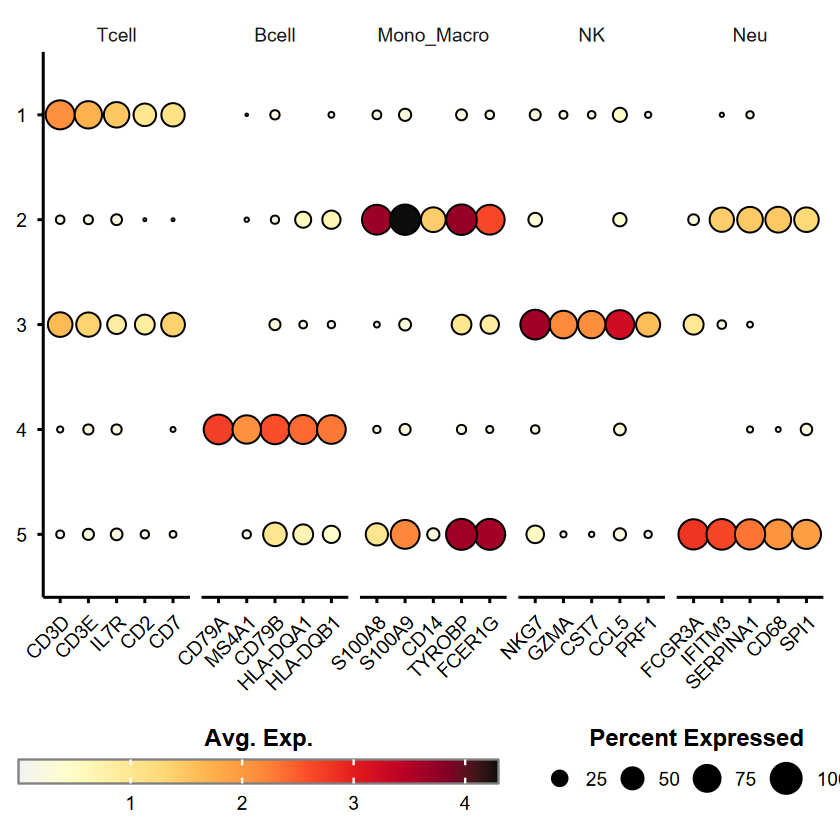

In [ ]:
# 使用 SCpubr 包绘制气泡图展示 marker 基因
library(SCpubr)

# 绘制气泡图
p_dot_cluster <- do_DotPlot(
  sample = seurat_use,
  assay = 'RNA',
  group.by = 'seurat_clusters',
  features = cell_type_markers,
  sequential.palette = 'YlOrRd',
  sequential.direction = 1
)

# 显示图形
print(p_dot_cluster)

In [ ]:
# 定义基于 marker 基因的细胞类型注释规则
annotation_cluster = list()
## T细胞 (根据marker基因CD3D, CD3E等，对应cluster 1)
annotation_cluster[['Tcell']] = c(1)
## B细胞 (根据marker基因CD79A, MS4A1等，对应cluster 4)
annotation_cluster[['Bcell']] = c(4)
## 单核巨噬细胞 (根据marker基因S100A8, S100A9, CD14等，对应cluster 2)
annotation_cluster[['Mono_Macro']] = c(2)
## NK细胞 (根据marker基因NKG7, GZMA, GZMB等，对应cluster 3)
annotation_cluster[['NK']] = c(3)
## 其他细胞类型 (根据marker基因FCGR3A, IFITM3等，对应cluster 5)
annotation_cluster[['SMC']] = c(5)

In [ ]:
# 将注释结果应用到 seurat 对象中
## 创建细胞类型注释向量
cell_type_annotation <- rep('Unknown', length(seurat_use@meta.data$seurat_clusters))
for (type in names(annotation_cluster)) {
  cell_type_annotation[seurat_use@meta.data$seurat_clusters %in% annotation_cluster[[type]]] <- type
}
## 添加到元数据
seurat_use@meta.data$cell_type <- cell_type_annotation

In [ ]:
# 查看最终注释结果
head(seurat_use@meta.data$cell_type)
table(seurat_use@meta.data$cell_type)

[1] "NK"         "Bcell"      "Tcell"      "Mono_Macro" "NK"        
[6] "Tcell"


     Bcell Mono_Macro         NK        SMC      Tcell 
       349        516        489        167       1117 

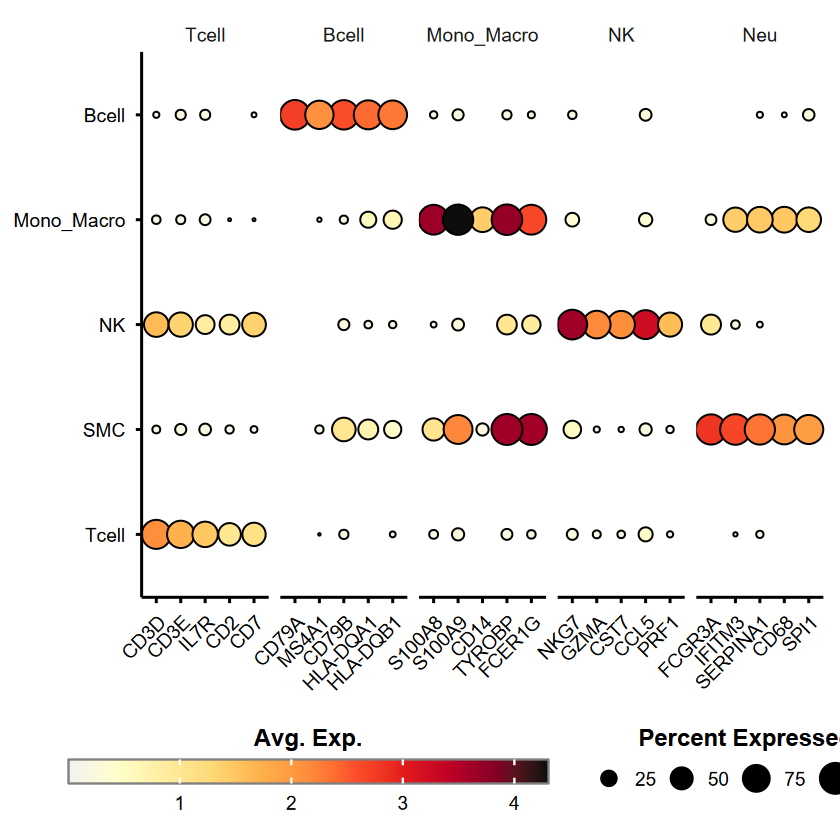

In [ ]:
# 使用 SCpubr 包绘制气泡图展示 marker 基因
library(SCpubr)

# 绘制气泡图
p_dot_cluster <- do_DotPlot(
  sample = seurat_use,
  assay = 'RNA',
  group.by = 'cell_type',
  features = cell_type_markers,
  sequential.palette = 'YlOrRd',
  sequential.direction = 1
)

# 显示图形
print(p_dot_cluster)